# CNN Demo: Trace Import and Quick Plot

Loads `k_alpha_traces.h5` from current working directory, crops samples 2000:6000, and plots first 10 traces.

noise_traces shape: (4000, 8000)
signal_traces shape: (4000, 8000)


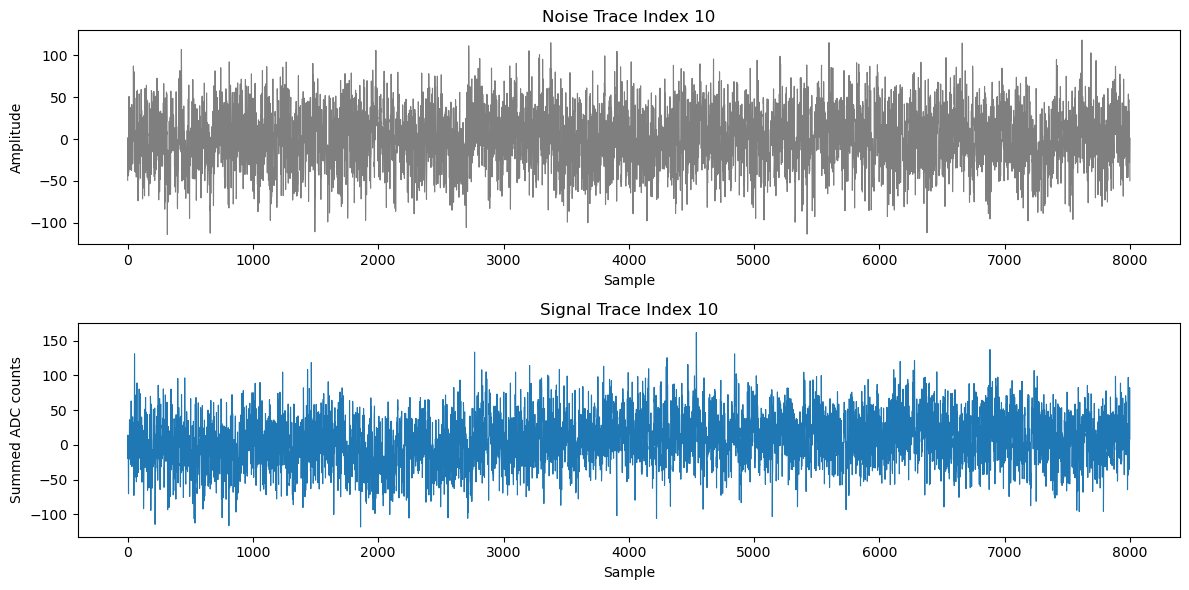

In [4]:
NOISE_PATH = DATA_DIR / "noise_traces_4000x8000.h5"
SIGNAL_PATH = DATA_DIR / "signal_vacuum_sum_crop_4000x8000.h5"
TRACE_IDX = 10

if not NOISE_PATH.exists():
    raise FileNotFoundError(f"Missing noise file at: {NOISE_PATH}")
if not SIGNAL_PATH.exists():
    raise FileNotFoundError(f"Missing signal file at: {SIGNAL_PATH}")

with h5py.File(NOISE_PATH, "r") as f_noise:
    noise_traces = np.asarray(f_noise["traces"][:], dtype=np.float64)

with h5py.File(SIGNAL_PATH, "r") as f_signal:
    signal_traces = np.asarray(f_signal["traces"][:], dtype=np.float64)

if TRACE_IDX >= noise_traces.shape[0]:
    raise IndexError(f"TRACE_IDX={TRACE_IDX} out of range for noise shape {noise_traces.shape}")
if TRACE_IDX >= signal_traces.shape[0]:
    raise IndexError(f"TRACE_IDX={TRACE_IDX} out of range for signal shape {signal_traces.shape}")

noise_10 = noise_traces[TRACE_IDX]
signal_10 = signal_traces[TRACE_IDX]

print("noise_traces shape:", noise_traces.shape)
print("signal_traces shape:", signal_traces.shape)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

axes[0].plot(noise_10, lw=0.8, color="tab:gray")
axes[0].set_title("Noise Trace Index 10")
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Amplitude")

axes[1].plot(signal_10, lw=0.8, color="tab:blue")
axes[1].set_title("Signal Trace Index 10")
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("Summed ADC counts")

plt.tight_layout()
plt.show()


In [5]:
# Save cropped traces to a single HDF5 file
OUT_PATH =  'cropped_traces_3000_7000.h5'

with h5py.File(OUT_PATH, 'w') as f:
    dset = f.create_dataset('traces', data=X_crop.astype(np.float32, copy=False), compression='gzip', compression_opts=4)
    dset.attrs['source_file'] = str(TRACE_PATH)
    dset.attrs['crop_start'] = 3000
    dset.attrs['crop_end'] = 7000

print('Saved:', OUT_PATH)
print('Dataset key: traces')
print('Saved shape:', X_crop.shape, 'dtype=float32')


NameError: name 'X_crop' is not defined